Data Acquisition and 200-day Moving Average Calculation

Φόρτωση και καθαρισμός δεδομένων...
Η ένωση ολοκληρώθηκε. Υπολογισμός 200-day Moving Averaage...
Επιτυχία! Το dataset περιλαμβάνει 1056 σειρές δεδομένων.

--- Δείγμα των τελικών δεδιμένων (Πρώτες 5 σειρές) ---
            AAPL_Raw    AAPL_MA SP500_Trend  VIX_Trend
Date                                                  
2022-03-04    163.17  152.81185    4,328.87      31.98
2022-03-07    159.30  152.97180    4,201.09      36.45
2022-03-08    157.44  153.13185    4,170.70      35.13
2022-03-09    162.95  153.31110    4,277.88      32.45
2022-03-10    158.52  153.46920    4,259.52      30.23


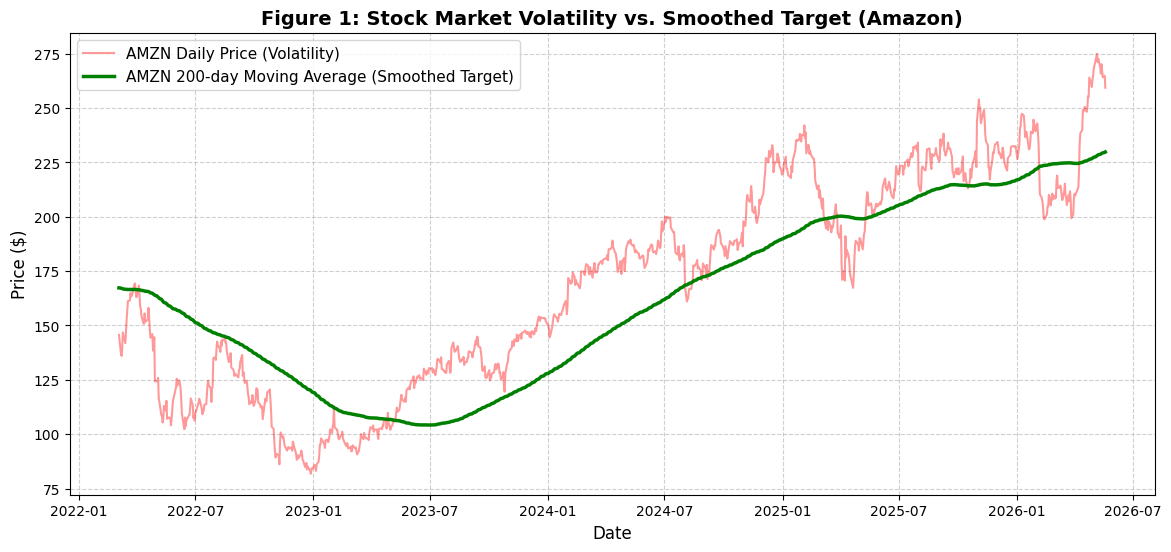

Το γράφημα αποθηκεύτηκε ως 'volatility_vs_smoothing_amzn.png'!


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Συνάρτηση για τη σωστή ανάγνωση των αρχείων
def load_financial_data(file_path, column_name):
  # Διαβάζουμε το CSV και ορίζουμε τη στήλη 'Date' ως Index
  df = pd.read_csv(file_path)
  df['Date'] = pd.to_datetime(df['Date'])
  df = df.set_index('Date')
  #Ταξινομούμε από την παλαιότερη ημερομηνία στην πιο πρόσφατη
  df = df.sort_index()
  #Κρατάμε μόνο τη στήλη 'Price' (Τιμή Κλεισίματος)
  return df[['Price']].rename(columns={'Price': column_name})

print("Φόρτωση και καθαρισμός δεδομένων...")

#Φόρτωση των 5 μετοχών
amzn = load_financial_data('Amazon.com Stock Price History.csv', 'AMZN_Raw')
aapl = load_financial_data('Apple Stock Price History.csv', 'AAPL_Raw')
ba = load_financial_data('Boeing Stock Price History.csv', 'BA_Raw')
gs = load_financial_data('Goldman Sachs Stock Price History.csv', 'GS_Raw')
lmt = load_financial_data('Lockheed Martin Stock Price History.csv', 'LMT_Raw')

#Φόρτωση των 2 δεικτών (S&P 500 και VIX)
sp500 = load_financial_data('S&P 500 Historical Data.csv', 'SP500_Trend')
vix = load_financial_data('CBOE Volatility Index Historical Data.csv', 'VIX_Trend')

#Ένώση όλων των DataFrames σε ένα ενιαίο με βάση την κοινή ημερομηνία
main_df = aapl.join([amzn, ba, gs, lmt, sp500, vix], how='inner')

print("Η ένωση ολοκληρώθηκε. Υπολογισμός 200-day Moving Averaage...")

#Υπολογισμός του 200-day Moving Average (MA) για κάθε μετοχή
tickers = ['AAPL', 'AMZN', 'BA', 'GS', 'LMT']
for ticker in tickers:
  main_df[f'{ticker}_MA'] = main_df[f'{ticker}_Raw'].rolling(window=200).mean()

#Αφαίρεση των πρώτων 200 ημερών (NaN) λόγω του Moving Average
main_df_cleaned = main_df.dropna()

print(f"Επιτυχία! Το dataset περιλαμβάνει {main_df_cleaned.shape[0]} σειρές δεδομένων.")
print("\n--- Δείγμα των τελικών δεδιμένων (Πρώτες 5 σειρές) ---")
print(main_df_cleaned[['AAPL_Raw', 'AAPL_MA', 'SP500_Trend', 'VIX_Trend']].head())

# ΔΗΜΙΟΥΡΓΙΑ ΓΡΑΦΗΜΑΤΟΣ (Section 3.2 - Volatilityy vs Smoothing)
plt.figure(figsize=(14, 6))
plt.plot(main_df_cleaned.index, main_df_cleaned['AMZN_Raw'], label='AMZN Daily Price (Volatility)', color='red', alpha=0.4)
plt.plot(main_df_cleaned.index, main_df_cleaned['AMZN_MA'], label='AMZN 200-day Moving Average (Smoothed Target)', color='green', linewidth=2.5)
plt.title('Figure 1: Stock Market Volatility vs. Smoothed Target (Amazon)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('volatility_vs_smoothing_amzn.png', dpi=300)
plt.show()
print("Το γράφημα αποθηκεύτηκε ως 'volatility_vs_smoothing_amzn.png'!")

Exploratory Data Analysis (Pearson Correlation) & MLP Model Training

/tmp/ipykernel_1033/479381591.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_df_cleaned['SP500_Trend'] = main_df_cleaned['SP500_Trend'].str.replace(',','').astype(float)


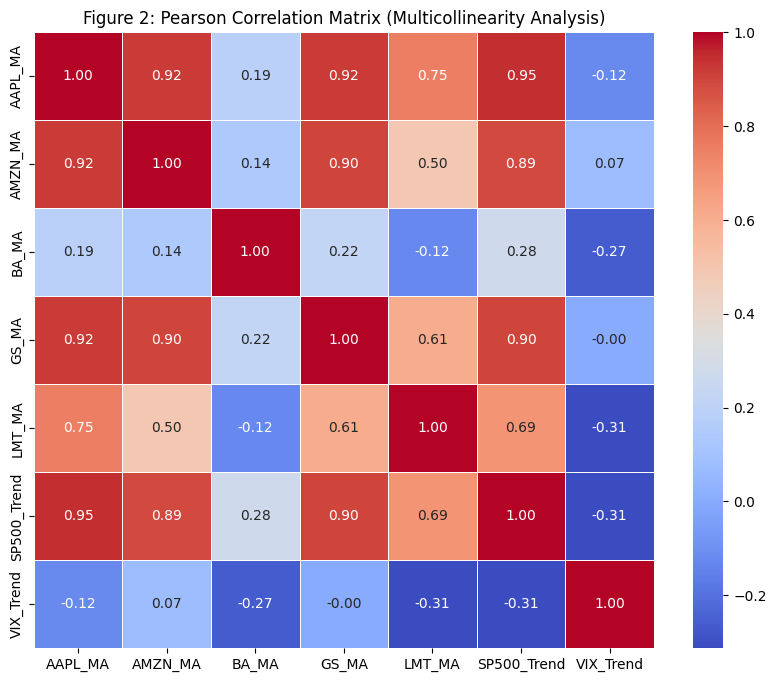

Ο πίνακας συσχέτισης Pearson αποθηκέυτηκε ως 'correlation_matrix.png'!

--- Αποτελέσματα Μοντέλου (AAPL) ---
 MAPE (Error): 0.6995%
 R^2 Score (Explanatory Power): 0.9746


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns

#Διόρθωση και καθαρισμός τύπων δεδομένων
#Μετατρέπουμε το S&P 500 σε καθαρό αριθμό (float) αφαιρώντας τα κόμματα
if main_df_cleaned['SP500_Trend'].dtype == 'O':
  main_df_cleaned['SP500_Trend'] = main_df_cleaned['SP500_Trend'].str.replace(',','').astype(float)

#Pearson Correlation (Section 5.1)
plt.figure(figsize=(10,8))
corr_matrix = main_df_cleaned[[f'{t}_MA' for t in tickers] +['SP500_Trend', 'VIX_Trend']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Figure 2: Pearson Correlation Matrix (Multicollinearity Analysis)')
plt.savefig('correlation_matrix.png', dpi=300)
plt.show()
print("Ο πίνακας συσχέτισης Pearson αποθηκέυτηκε ως 'correlation_matrix.png'!\n")

#Κατασκευή Feature Matrix(Sliding Window)
#Θα φτιάξουμε τις εισόδυς (X) και τους στόχους (y) για κάθε μετοχή ξεχωριστά
#Input X: [MA_t-5, MA_t-4, MA_t-3, MA_t-2, MA_t-1, Trend_t-1]
#Target y: [MA_t]
def create_sliding_window(df, ticker):
  X, y = [], []
  ma_col = f'{ticker}_MA'
  trend_col = 'SP500_Trend' #Χρησιμοποιούμε τον S&P 500 ως Trend_t-1
  ma_values = df[ma_col].values
  trend_values = df[trend_col].values

  #Ξεκινάμε από το 5 για να έχουμε 5 προηγούμενες  μέρες
  for i in range(5, len(df)):
    X_features = [
        ma_values[i-5], #MA_t-5
        ma_values[i-4], #MA_t-4
        ma_values[i-3], #MA_t-3
        ma_values[i-2], #MA_t-2
        ma_values[i-1], #MA_t-1
        trend_values[i-1] #Trend_t-1
    ]
    X.append(X_features)
    y.append(ma_values[i]) #Target: MA_t
  return np.array(X), np.array(y)

#Παράδειγμα εκπαίδευσης για την Apple(AAPL)
#(Ίδια διαδικασία και για τις άλλες 4 μετοχές)
X_aapl, y_aapl = create_sliding_window(main_df_cleaned, 'AAPL')

#TRAIN/TEST SPLIT (80% Train, 20% Hold-out Test Set)
#! Στα Time-Series δεν κάνουμε shuffle. Κρατλαμε το τελευταίο 20% χρονολογικά.
split_index =int(len(X_aapl)*0.8)
X_train, X_test = X_aapl[:split_index], X_aapl[split_index:]
y_train, y_test = y_aapl[:split_index], y_aapl[split_index:]

#Normalization (Scaling)
scaler_X = MinMaxScaler(feature_range=(0,1))
scaler_y = MinMaxScaler(feature_range=(0,1))
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

#To Scikit-learn θέλει 2D array για τον scaler
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

#Εκπάιδευση MLP Regressor (section 4.3)
#Δοκιμάζουμε με relu(μπορούμε να το αλλάξουμε σε 'logistic' για το report μας)
mlp = MLPRegressor(hidden_layer_sizes=(20,), activation='relu', solver='adam', max_iter=500, random_state=42)
mlp.fit(X_train_scaled, y_train_scaled)

#Πρόβλεψη & Αξιολόγηση (Metrics)
y_pred_scaled = mlp.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

#Υπολογισμός MAPE (Mean Absolute Percentage Error)
mape = np.mean(np.abs((y_test - y_pred)/y_test))*100
r2 = r2_score(y_test, y_pred)

print("--- Αποτελέσματα Μοντέλου (AAPL) ---")
print(f" MAPE (Error): {mape:.4f}%")
print(f" R^2 Score (Explanatory Power): {r2:.4f}")

10-Day Recursive Multi-step Forecasting & Growth Analysis

Έναρξη Recursive Forecasting για τις 5 μετοχές (20-30 Μαΐου)...

Οι προβλέψεις ολοκληρώθηκαν!
--- Πίνακας Προβλέψεων Κινητού Μέσου Όρου (20-29 Μαΐου 2026) ---
              AAPL        AMZN          BA          GS         LMT
May 20  258.193949  226.841213  218.528619  846.664454  517.864409
May 21  257.733460  225.886598  218.046293  847.935573  514.121616
May 22  257.227225  224.819779  217.460493  849.330636  510.370227
May 23  257.123513  224.253773  217.140069  850.598814  508.676932
May 24  255.969889  222.289598  216.349051  852.258745  502.029469
May 25  255.551763  221.411756  215.936617  853.442425  499.692797
May 26  254.918109  220.203432  215.331643  854.796224  496.357975
May 27  254.612196  219.413513  214.968422  856.016301  494.714875
May 28  253.787816  217.935282  214.336673  857.400904  490.728197
May 29  253.365131  217.059993  213.955219  858.529975  489.126461

Αναμενόμενη ποσοστιαία μεταβολή (%) από 20 έως 29 Μαΐου:
AAPL: -1.8702%
AMZN: -4.3119%
BA: -2.0928%
GS:

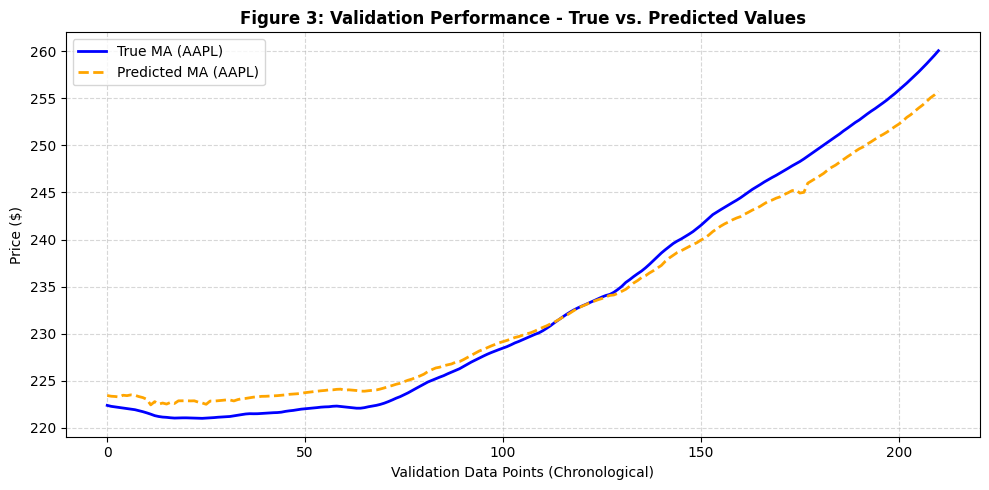

Το γράφημα επικύρωσης αποθηκεύτηκε ως 'validation_performance.png'!


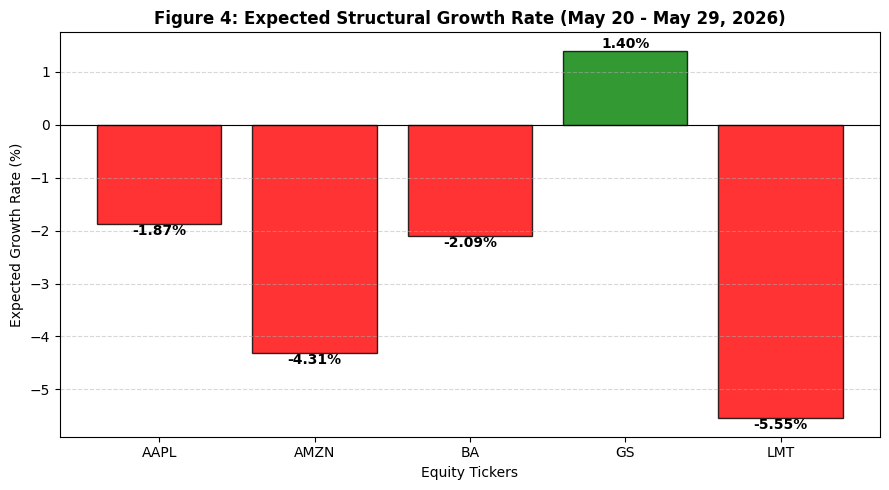

Το γράφημα αποδόσεων αποθηκεύτηκε ως 'expected_growth_rates.png'!


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor

tickers = ['AAPL', 'AMZN', 'BA', 'GS', 'LMT']
future_predictions = {}
growth_rates = {}

print("Έναρξη Recursive Forecasting για τις 5 μετοχές (20-30 Μαΐου)...")

for ticker in tickers:
    #Κατασκευή Sliding Window για τη συγκεκριμένη μετοχή
    X, y = create_sliding_window(main_df_cleaned, ticker)

    #Normalization
    scaler_X = MinMaxScaler(feature_range=(0, 1))
    scaler_y = MinMaxScaler(feature_range=(0, 1))
    X_scaled = scaler_X.fit_transform(X)
    y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

    #Εκπαίδευση του μοντέλου σε όλα τα ιστορικά δεδομένα για μέγιστη ακρίβεια στο μέλλον
    mlp_full = MLPRegressor(hidden_layer_sizes=(20,), activation='relu', solver='adam', max_iter=500, random_state=42)
    mlp_full.fit(X_scaled, y_scaled)

    #Προετοιμασία για το Recursive Loop (Παίρνουμε το τελευταίο διαθέσιμο παράθυρο)
    last_5_ma = list(main_df_cleaned[f'{ticker}_MA'].values[-5:])
    last_trend = main_df_cleaned['SP500_Trend'].values[-1]
    predictions_10d = []

    #Το Recursive Loop των 10 βημάτων
    for step in range(10):
        #Φτιάχνουμε το vector εισόδου: [MA_t-5, MA_t-4, MA_t-3, MA_t-2, MA_t-1, Trend_t-1]
        current_input = np.array(last_5_ma + [last_trend]).reshape(1, -1)
        #Scaling της εισόδου
        current_input_scaled = scaler_X.transform(current_input)
        #Πρόβλεψη (σε scaling κλίμακα)
        pred_scaled = mlp_full.predict(current_input_scaled)
        #Αντίστροφο scaling για να το έχουμε σε δολάρια
        pred_usd = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()[0]
        #Αποθήκευση της πρόβλεψης
        predictions_10d.append(pred_usd)
        #Recursive Shift: Διώχνουμε την παλιότερη τιμή και προσθέτουμε την πρόβλεψη!
        last_5_ma.pop(0)  #Αφαίρεση του MA_t-5
        last_5_ma.append(pred_usd)  #Η τωρινή πρόβλεψη γίνεται το νέο MA_t-1 για το επόμενο βήμα
    future_predictions[ticker] = predictions_10d

#Μετατροπή των προβλέψεων σε ένα καθαρό DataFrame
future_dates = ['May 20', 'May 21', 'May 22', 'May 23', 'May 24', 'May 25', 'May 26', 'May 27', 'May 28', 'May 29']
pred_df = pd.DataFrame(future_predictions, index=future_dates)

print("\nΟι προβλέψεις ολοκληρώθηκαν!")
print("--- Πίνακας Προβλέψεων Κινητού Μέσου Όρου (20-29 Μαΐου 2026) ---")
print(pred_df)

#Υπολογισμός Ποσοστιαίας Ανάπτυξης (Για την επενδυτική απόφαση)
print("\nΑναμενόμενη ποσοστιαία μεταβολή (%) από 20 έως 29 Μαΐου:")
for ticker in tickers:
    start_val = pred_df.loc['May 20', ticker]
    end_val = pred_df.loc['May 29', ticker]
    growth = ((end_val - start_val) / start_val) * 100
    growth_rates[ticker] = growth
    print(f"{ticker}: {growth:.4f}%")

#ΤΕΛΙΚΟ ΦΙΝΙΡΙΣΜΑ: ΑΥΤΟΜΑΤΗ ΔΗΜΙΟΥΡΓΙΑ ΓΡΑΦΗΜΑΤΩΝ ΓΙΑ ΤΟ REPORT
print("\n Δημιουργία και αποθήκευση τελικών γραφημάτων...")

#Γράφημα Επικύρωσης Μοντέλου (True vs Predicted 200-day MA για την Apple)
plt.figure(figsize=(10, 5))
plt.plot(y_test, label='True MA (AAPL)', color='blue', linewidth=2)
plt.plot(y_pred, label='Predicted MA (AAPL)', color='orange', linestyle='--', linewidth=2)
plt.title('Figure 3: Validation Performance - True vs. Predicted Values', fontsize=12, fontweight='bold')
plt.xlabel('Validation Data Points (Chronological)', fontsize=10)
plt.ylabel('Price ($)', fontsize=10)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('validation_performance.png', dpi=300)
plt.show()
print("Το γράφημα επικύρωσης αποθηκεύτηκε ως 'validation_performance.png'!")

#Ραβδόγραμμα Αναμενόμενης Απόδοσης (Expected Growth Rates) για το Section 8
plt.figure(figsize=(9, 5))
colors = ['red' if x < 0 else 'green' for x in growth_rates.values()]
bars = plt.bar(growth_rates.keys(), growth_rates.values(), color=colors, edgecolor='black', alpha=0.8)

#Προσθήκη των ποσοστών πάνω από κάθε μπάρα για ευκολία στην ανάγνωση
for bar in bars:
    yval = bar.get_height()
    va_dir = 'bottom' if yval >= 0 else 'top'
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f"{yval:.2f}%", ha='center', va=va_dir, fontweight='bold')

plt.axhline(0, color='black', linewidth=0.8, linestyle='-') #Γραμμή του μηδενός
plt.title('Figure 4: Expected Structural Growth Rate (May 20 - May 29, 2026)', fontsize=12, fontweight='bold')
plt.ylabel('Expected Growth Rate (%)', fontsize=10)
plt.xlabel('Equity Tickers', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('expected_growth_rates.png', dpi=300)
plt.show()
print("Το γράφημα αποδόσεων αποθηκεύτηκε ως 'expected_growth_rates.png'!")